In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import kurtosis

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
mat = loadmat('../data/Normal_1.mat')
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X098_DE_time', 'X098_FE_time'])


In [5]:
print(mat['X098_DE_time'].shape)
print(mat['X098_FE_time'].dtype)

(483903, 1)
float64


In [6]:
mat = loadmat('../data/IR007_1.mat')
for key in mat.keys():
    if not key.startswith('__'):
        print(f"{key}: shape={mat[key].shape}, dtype={mat[key].dtype}")

X106_DE_time: shape=(121991, 1), dtype=float64
X106_FE_time: shape=(121991, 1), dtype=float64
X106_BA_time: shape=(121991, 1), dtype=float64
X106RPM: shape=(1, 1), dtype=uint16


In [7]:
mat = loadmat('../data/B007_1.mat')
for key in mat.keys():
    if not key.startswith('__'):
        print(f"{key}: shape={mat[key].shape}, dtype={mat[key].dtype}")

X119_DE_time: shape=(121410, 1), dtype=float64
X119_FE_time: shape=(121410, 1), dtype=float64
X119_BA_time: shape=(121410, 1), dtype=float64
X119RPM: shape=(1, 1), dtype=uint16


In [8]:
mat = loadmat('../data/OR007@6_1.mat')
for key in mat.keys():
    if not key.startswith('__'):
        print(f"{key}: shape={mat[key].shape}, dtype={mat[key].dtype}")

X131_DE_time: shape=(122426, 1), dtype=float64
X131_FE_time: shape=(122426, 1), dtype=float64
X131_BA_time: shape=(122426, 1), dtype=float64
X131RPM: shape=(1, 1), dtype=uint16


In [9]:
files = {
    'Healthy': {
        'path': '../data/Normal_1.mat',
        'var':  'X098_DE_time',
        'rpm':  1772,
    },
    'Inner Race': {
        'path': '../data/IR007_1.mat',
        'var':  'X106_DE_time',
        'rpm':  1772,
    },
    'Ball': {
        'path': '../data/B007_1.mat',
        'var':  'X119_DE_time',
        'rpm':  1772,
    },
    'Outer Race': {
        'path': '../data/OR007@6_1.mat',
        'var':  'X131_DE_time',
        'rpm':  1772,
    },
}

fs = 12000  # Hz, sampling frequency for drive-end channel

In [10]:
signals = {}
for condition, info in files.items():
    mat = loadmat(info['path'])
    signals[condition] = mat[info['var']].flatten()

In [11]:
for condition, signal in signals.items():
    print(f"{condition}: {signal.shape}, duration = {len(signal)/fs:.2f} s")

Healthy: (483903,), duration = 40.33 s
Inner Race: (121991,), duration = 10.17 s
Ball: (121410,), duration = 10.12 s
Outer Race: (122426,), duration = 10.20 s


In [12]:
for condition, signal in signals.items():
    print(f"{condition}: min = {signal.min():.3f}, max = {signal.max():.3f}")

Healthy: min = -0.346, max = 0.318
Inner Race: min = -1.403, max = 1.581
Ball: min = -0.660, max = 0.640
Outer Race: min = -3.012, max = 3.112


In [13]:
stats = {}
for condition, signal in signals.items():
    stats[condition] = {
        'N samples': len(signal),
        'Duration (s)': len(signal) / fs,
        'Mean': np.mean(signal),
        'Std': np.std(signal),
        'Min': signal.min(),
        'Max': signal.max(),
        'RMS': np.sqrt(np.mean(signal**2)),
        'Peak': np.max(np.abs(signal)),
        'Crest Factor': np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2)),
        'Kurtosis': kurtosis(signal, fisher=False),
    }

df_stats = pd.DataFrame(stats).T  # .T transposes so conditions become rows
df_stats.round(3)

,N samples,Duration (s),Mean,Std,Min,Max,RMS,Peak,Crest Factor,Kurtosis
Healthy,483903.0,40.325,0.013,0.065,-0.346,0.318,0.066,0.346,5.213,2.931
Inner Race,121991.0,10.166,0.006,0.293,-1.403,1.581,0.293,1.581,5.397,5.542
Ball,121410.0,10.118,0.004,0.139,-0.660,0.640,0.139,0.660,4.743,2.964
Outer Race,122426.0,10.202,0.004,0.592,-3.012,3.112,0.592,3.112,5.258,7.595


In [14]:
t = np.arange(len(signal)) / fs

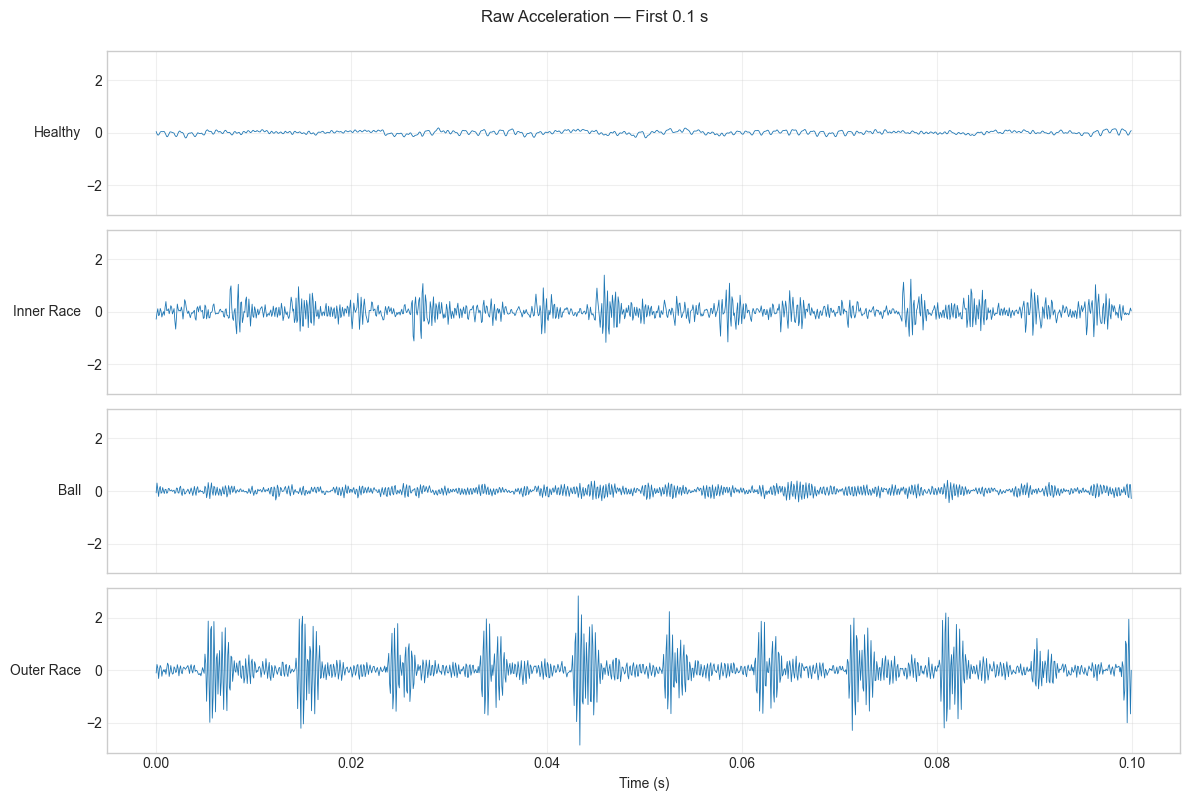

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True, sharey=True)

n_samples = int(0.1 * fs)  # 1200 samples = 0.1 seconds

for ax, (condition, signal) in zip(axes, signals.items()):
    t = np.arange(n_samples) / fs
    ax.plot(t, signal[:n_samples], linewidth=0.6)
    ax.set_ylabel(condition, rotation=0, ha='right', va='center', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Raw Acceleration — First 0.1 s', fontsize=12, y=0.995)
fig.tight_layout()
fig.savefig('../figures/timeseries_0p1s.png', dpi=150, bbox_inches='tight')
plt.show()

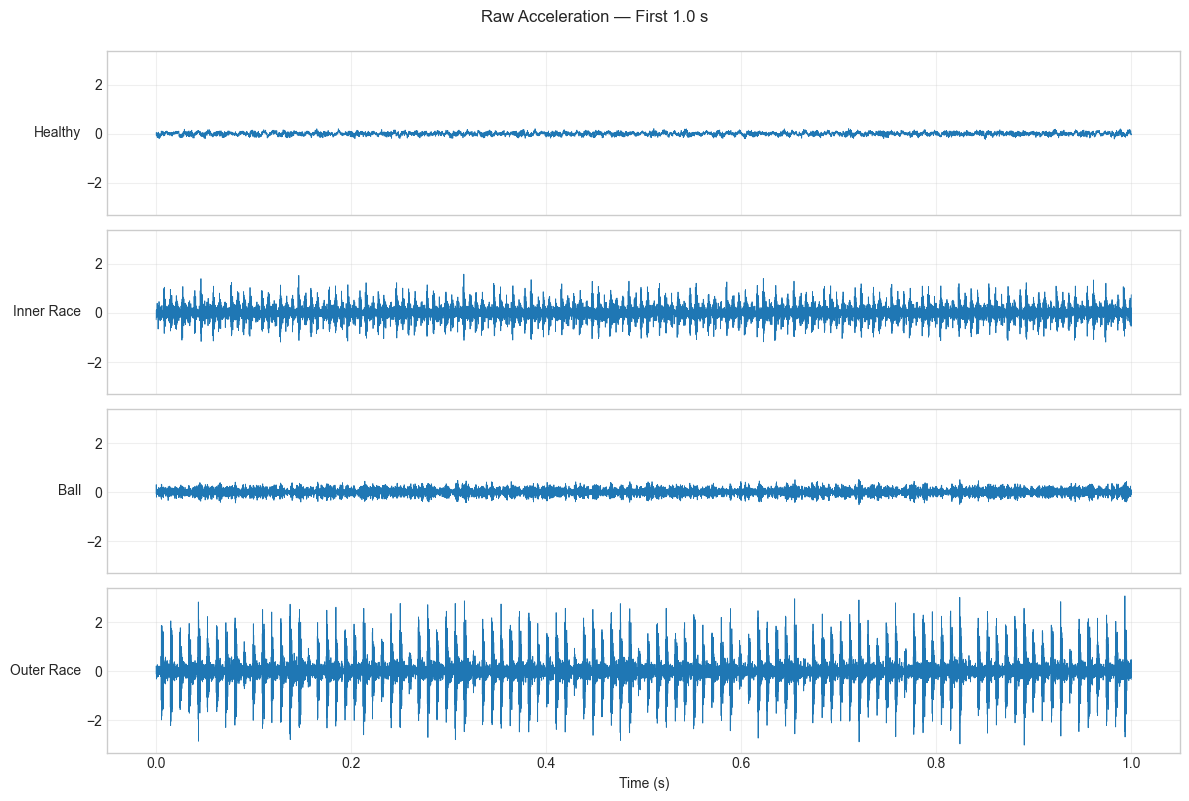

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True, sharey=True)

n_samples = int(1.0 * fs)  # 1200 samples = 0.1 seconds

for ax, (condition, signal) in zip(axes, signals.items()):
    t = np.arange(n_samples) / fs
    ax.plot(t, signal[:n_samples], linewidth=0.6)
    ax.set_ylabel(condition, rotation=0, ha='right', va='center', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Raw Acceleration — First 1.0 s', fontsize=12, y=0.995)
fig.tight_layout()
fig.savefig('../figures/timeseries_1s.png', dpi=150, bbox_inches='tight')
plt.show()